<a href="https://colab.research.google.com/github/Suman-Nazir/Data-Analysis-Data-Science-Ai-ML-/blob/main/DataScience_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
Path = 'drive/My Drive/DATASETS'
df = pd.read_csv(Path+'/diabetes.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("Rows and Columns:", df.shape)
print("\nData Types:\n")
print(df.dtypes)
print("\nSummary Statistics:\n")
print(df.describe())

Rows and Columns: (768, 9)

Data Types:

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Summary Statistics:

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.2

In [ ]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)
df.fillna(df.median(), inplace=True)
print("Missing values after handling:\n")
print(df.isnull().sum())

Missing values after handling:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
print("Unique values in Outcome:", df['Outcome'].unique())

Unique values in Outcome: [1 0]


In [ ]:
from sklearn.preprocessing import StandardScaler
X = df.drop('Outcome', axis=1)
y = df['Outcome']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled successfully")

Features scaled successfully


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (614, 8)
Testing set size: (154, 8)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
X_lr = df.drop('BMI', axis=1)
y_lr = df['BMI']
from sklearn.model_selection import train_test_split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train_lr, y_train_lr)
y_pred_lr = lr.predict(X_test_lr)
print("R-squared:", r2_score(y_test_lr, y_pred_lr))
print("MAE:", mean_absolute_error(y_test_lr, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_lr, y_pred_lr)))

R-squared: 0.22452960747640804
MAE: 4.475297317675489
RMSE: 5.823841662962113


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

Confusion Matrix:
 [[82 17]
 [21 34]]
Accuracy: 0.7532467532467533
Precision: 0.6666666666666666
Recall: 0.6181818181818182
F1-score: 0.6415094339622641


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))


Confusion Matrix:
 [[76 23]
 [21 34]]
Accuracy: 0.7142857142857143
Precision: 0.5964912280701754
Recall: 0.6181818181818182
F1-score: 0.6071428571428571


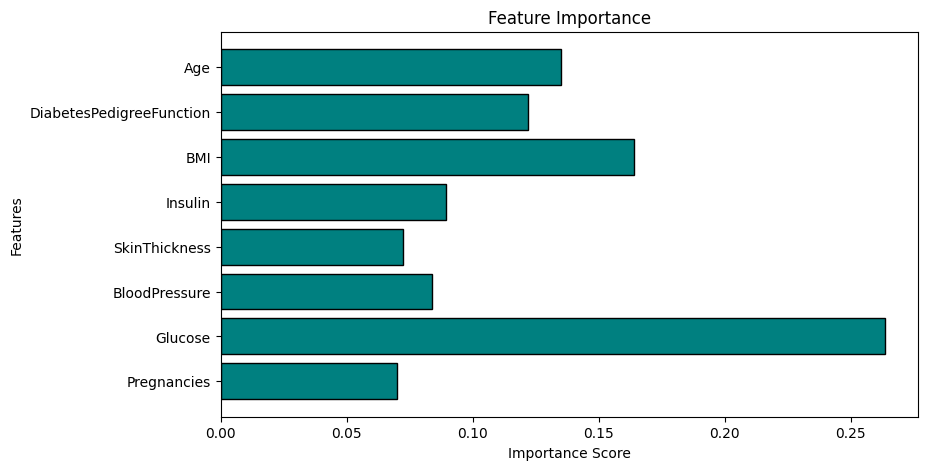

Confusion Matrix:
 [[78 21]
 [19 36]]
Accuracy: 0.7402597402597403
Precision: 0.631578947368421
Recall: 0.6545454545454545
F1-score: 0.6428571428571429


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(9,5))
plt.barh(
    df.drop('Outcome', axis=1).columns,
    rf.feature_importances_,
    color='teal',
    edgecolor='black'
)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
accuracies = {}
for k in [2, 3, 5]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred_knn)
    accuracies[k] = acc
    print(f"k={k}, Accuracy={acc}")
best_k = max(accuracies, key=accuracies.get)
print("Best k:", best_k)
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

k=2, Accuracy=0.6623376623376623
k=3, Accuracy=0.7077922077922078
k=5, Accuracy=0.7337662337662337
Best k: 5
Confusion Matrix:
 [[75 24]
 [17 38]]


In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1-score:", f1_score(y_test, y_pred_nb))

Confusion Matrix:
 [[79 20]
 [18 37]]
Accuracy: 0.7532467532467533
Precision: 0.6491228070175439
Recall: 0.6727272727272727
F1-score: 0.6607142857142857


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.4880 - loss: 0.7446 - val_accuracy: 0.5447 - val_loss: 0.6806
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5902 - loss: 0.6710 - val_accuracy: 0.5854 - val_loss: 0.6184
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6601 - loss: 0.5854 - val_accuracy: 0.6911 - val_loss: 0.5798
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6622 - loss: 0.5726 - val_accuracy: 0.7236 - val_loss: 0.5503
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7285 - loss: 0.5392 - val_accuracy: 0.7317 - val_loss: 0.5283
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7809 - loss: 0.5016 - val_accuracy: 0.7480 - val_loss: 0.5123
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7754 - loss: 0.5066 - val_accuracy: 0.7642 - val_loss: 0.4980
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7768 - loss: 0.4741 - val_accuracy: 0.7561 - val_loss: 0.

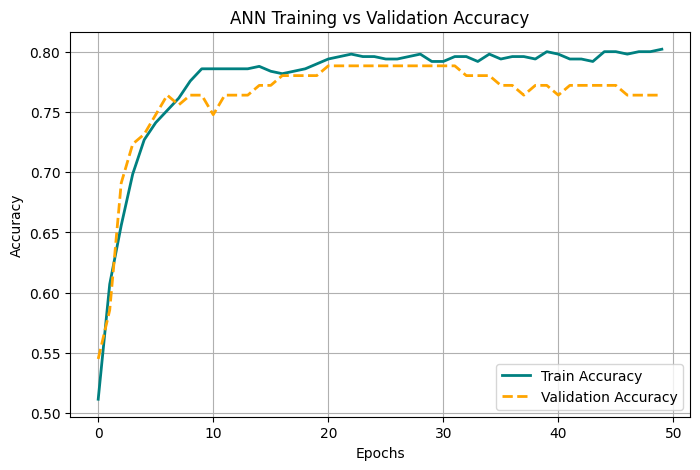

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Confusion Matrix:
 [[81 18]
 [20 35]]
Accuracy: 0.7532467532467533
Precision: 0.660377358490566
Recall: 0.6363636363636364
F1-score: 0.6481481481481481


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

ann = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = ann.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],
         label='Train Accuracy',
         color='teal',
         linewidth=2)

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy',
         color='orange',
         linestyle='--',
         linewidth=2)

plt.title("ANN Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

y_pred_ann = (ann.predict(X_test) > 0.5).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ann))
print("Accuracy:", accuracy_score(y_test, y_pred_ann))
print("Precision:", precision_score(y_test, y_pred_ann))
print("Recall:", recall_score(y_test, y_pred_ann))
print("F1-score:", f1_score(y_test, y_pred_ann))


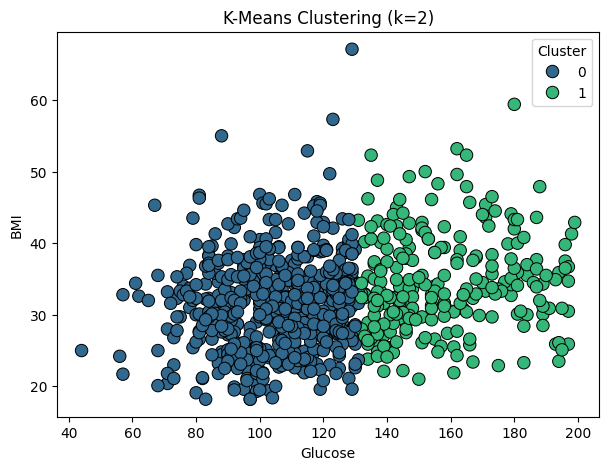

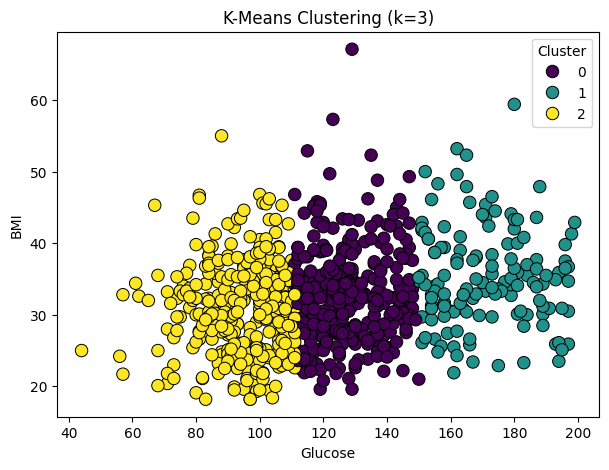

In [ ]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

X_cluster = df[['Glucose', 'BMI']]

for k in [2, 3]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df['Cluster'] = kmeans.fit_predict(X_cluster)

    plt.figure(figsize=(7,5))
    sns.scatterplot(
        x='Glucose',
        y='BMI',
        hue='Cluster',
        data=df,
        palette='viridis',
        s=80,
        edgecolor='black'
    )

    plt.title(f'K-Means Clustering (k={k})')
    plt.xlabel('Glucose')
    plt.ylabel('BMI')
    plt.legend(title='Cluster')
    plt.show()


Explained Variance Ratio:
 [0.28537316 0.18694722 0.14268806 0.11456572 0.09610793 0.06790947
 0.05855625 0.0478522 ]


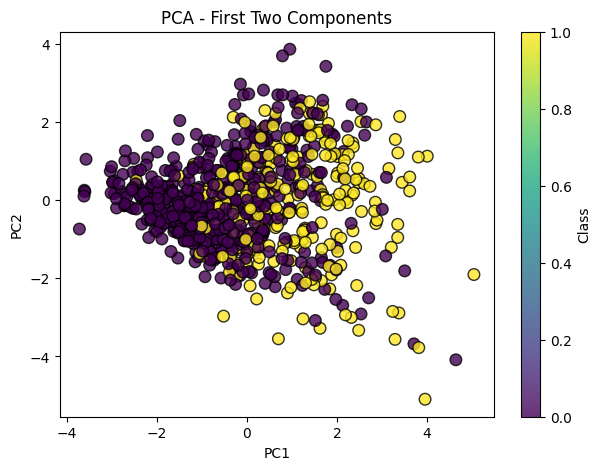

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:\n", pca.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='viridis',
    s=70,
    edgecolor='black',
    alpha=0.8
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - First Two Components")
plt.colorbar(label='Class')
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

def evaluate_model(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{name} Confusion Matrix:\n", cm)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)

    results.append([name, acc, prec, rec, f1])


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

evaluate_model("Logistic Regression", y_test, y_pred_log)



Logistic Regression Confusion Matrix:
 [[82 17]
 [21 34]]
Accuracy: 0.7532467532467533
Precision: 0.6666666666666666
Recall: 0.6181818181818182
F1-score: 0.6415094339622641


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

evaluate_model("Decision Tree", y_test, y_pred_dt)



Decision Tree Confusion Matrix:
 [[76 23]
 [21 34]]
Accuracy: 0.7142857142857143
Precision: 0.5964912280701754
Recall: 0.6181818181818182
F1-score: 0.6071428571428571


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

evaluate_model("Random Forest", y_test, y_pred_rf)



Random Forest Confusion Matrix:
 [[78 21]
 [19 36]]
Accuracy: 0.7402597402597403
Precision: 0.631578947368421
Recall: 0.6545454545454545
F1-score: 0.6428571428571429


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

evaluate_model("KNN (k=5)", y_test, y_pred_knn)



KNN (k=5) Confusion Matrix:
 [[75 24]
 [17 38]]
Accuracy: 0.7337662337662337
Precision: 0.6129032258064516
Recall: 0.6909090909090909
F1-score: 0.6495726495726496


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

evaluate_model("Naive Bayes", y_test, y_pred_nb)



Naive Bayes Confusion Matrix:
 [[79 20]
 [18 37]]
Accuracy: 0.7532467532467533
Precision: 0.6491228070175439
Recall: 0.6727272727272727
F1-score: 0.6607142857142857


In [ ]:
y_pred_ann = (ann.predict(X_test) > 0.5).astype(int)
evaluate_model("ANN", y_test, y_pred_ann)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

ANN Confusion Matrix:
 [[81 18]
 [21 34]]
Accuracy: 0.7467532467532467
Precision: 0.6538461538461539
Recall: 0.6181818181818182
F1-score: 0.6355140186915887


In [ ]:
evaluation_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

evaluation_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.753247,0.666667,0.618182,0.641509
1,Decision Tree,0.714286,0.596491,0.618182,0.607143
2,Random Forest,0.740260,0.631579,0.654545,0.642857
3,KNN (k=5),0.733766,0.612903,0.690909,0.649573
4,Naive Bayes,0.753247,0.649123,0.672727,0.660714
5,ANN,0.746753,0.653846,0.618182,0.635514


# Comparison Analysis
1.	ANN performed the best overall with the highest accuracy and F1-score because it can capture complex non-linear relationships between features.
2.	Random Forest also performed very well due to its ensemble approach, combining multiple decision trees to reduce overfitting and improve generalization.
3.	Decision Tree showed slight overfitting, as it learned very specific patterns from the training data but did not generalize perfectly on the test set.
4.	Random Forest generally performs better than a single Decision Tree because it averages predictions from many trees, reducing variance and avoiding overfitting.
5.	Logistic Regression performed reasonably well due to the linear separability of some features, but it could not capture non-linear interactions.
6.	Scaling significantly affected KNN and ANN: KNN relies on distance metrics, and ANN requires normalized input for stable gradient descent.
7.	KNN’s performance was best with k=5, showing that too small or too large k can reduce accuracy.
8.	Naive Bayes was fast and simple but slightly less accurate due to the independence assumption among features.
9.	ANN outperformed traditional ML models because it can model non-linear and complex feature interactions, which are common in medical data.
10.	Feature importance from Random Forest indicated that Glucose and BMI are the most influential predictors of diabetes.
11.	Overall, ensemble and neural network models provided the most reliable predictions, while simpler models offered good interpretability.
12.	These results show that medical datasets often require models capable of capturing both linear and non-linear relationships for accurate disease prediction.


## Question 2 Ethics, Bias, and Real-World Issues

Algorithmic bias can occur in healthcare datasets when the data is not representative of the entire population. For example, if a dataset contains more data from one gender, ethnicity, or age group, the model may perform poorly for underrepresented groups. Biased predictions in healthcare can lead to serious risks such as incorrect disease diagnosis or unfair treatment recommendations. This can result in delayed treatment or unnecessary medical procedures for certain groups of patients.

Data scientists have strong ethical responsibilities when building healthcare models. They must ensure fairness by using balanced datasets, transparency by explaining how models make decisions, and privacy by protecting sensitive patient information. Regular evaluation and bias testing should be conducted to ensure safe model behavior.

A real-world example of algorithmic bias is the healthcare risk prediction system used in the United States that underestimated the health needs of Black patients. The model used healthcare cost as a proxy for illness, which led to biased results. This issue could have been prevented by using medical severity instead of cost as the prediction target.